In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cpi = pd.read_csv("../data/historicalcpi.csv")
ppi = pd.read_csv("../data/historicalppi.csv")
forecast = pd.read_csv("../data/CPIForecast.csv")

In [15]:
avg_cpi = (
    cpi.groupby("Consumer Price Index item")["Percent change"]
       .mean()
       .sort_values(ascending=False)
)

avg_cpi.head(15)

Consumer Price Index item
Sugar and sweets               4.598077
Fresh fruits                   4.507692
Food away from home            4.269231
Cereals and bakery products    4.257692
Nonalcoholic beverages         4.230769
Beef and veal                  4.223077
Fish and seafood               4.207692
Fresh fruits and vegetables    4.192308
Fruits and vegetables          4.003846
Fresh vegetables               3.986538
Fats and oils                  3.967308
All food                       3.863462
Other foods                    3.807692
Food at home                   3.655769
Eggs                           3.584615
Name: Percent change, dtype: float64

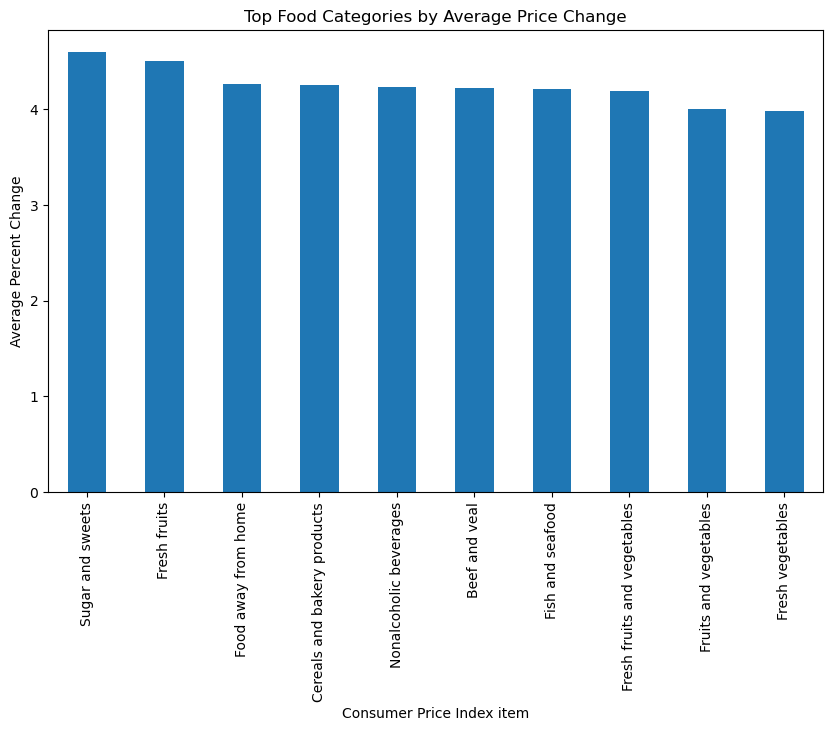

In [16]:
plt.figure(figsize=(10,6))

avg_cpi.head(10).plot(kind="bar")

plt.title("Top Food Categories by Average Price Change")
plt.ylabel("Average Percent Change")
plt.show()

In [17]:
all_food = cpi[
    cpi["Consumer Price Index item"]=="All food"
]

all_food.head()

,Consumer Price Index item,Year,Percent change
0,All food,1974,14.3
1,All food,1975,8.5
2,All food,1976,3.0
3,All food,1977,6.3
4,All food,1978,9.9


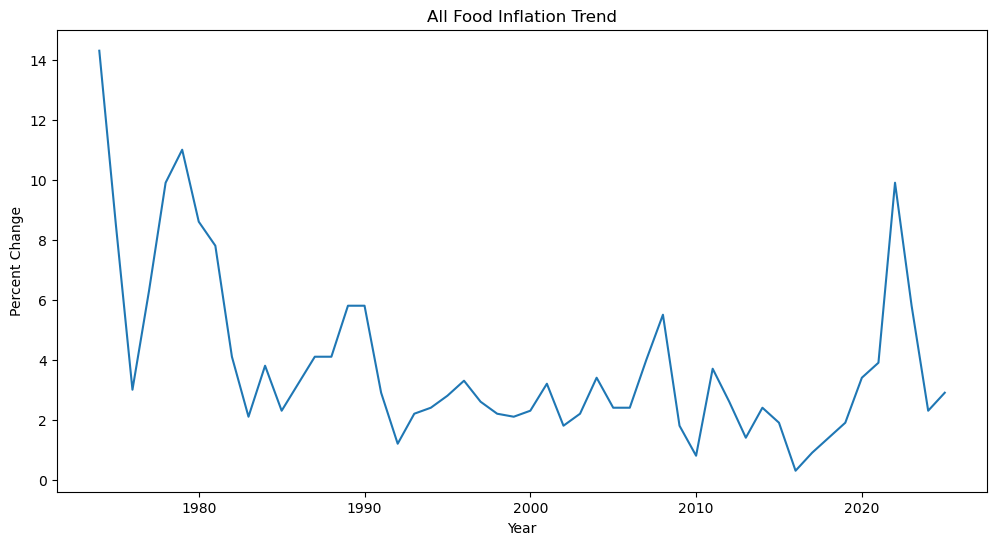

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    all_food["Year"],
    all_food["Percent change"]
)

plt.title("All Food Inflation Trend")
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.show()

In [19]:
farm_eggs = ppi[
    ppi["Producer Price Index item"]=="Farm-level eggs"
]

farm_eggs.head()

,Producer Price Index item,Year,Percent change
364,Farm-level eggs,1974,-3.0
365,Farm-level eggs,1975,-0.6
366,Farm-level eggs,1976,12.1
367,Farm-level eggs,1977,-9.6
368,Farm-level eggs,1978,-2.1


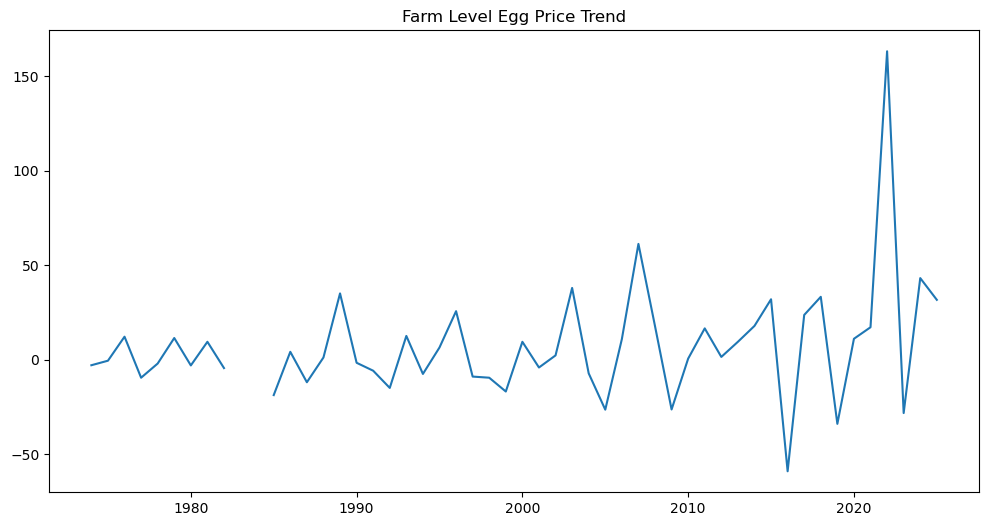

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    farm_eggs["Year"],
    farm_eggs["Percent change"]
)

plt.title("Farm Level Egg Price Trend")
plt.show()

In [21]:
forecast["Attribute"].unique()

array(['Relative importance', 'Month-to-month March 2026 to April 2026',
       'Year-over-year April 2025 to April 2026',
       'Year-to-date avg. 2026 to avg. 2025', 'Annual 2023',
       'Annual 2024', 'Annual 2025', '20-year historical average',
       'Lower bound of prediction interval 2026',
       'Mid point of prediction interval 2026',
       'Upper bound of prediction interval 2026'], dtype=object)

In [22]:
forecast.head(20)

,Top-level,Aggregate,Mid-level,Low-level,Disaggregate,Attribute,Unit,Value
0,All food,NaN,NaN,NaN,NaN,Relative importance,Percent,100.0
1,All food,NaN,NaN,NaN,NaN,Month-to-month March 2026 to April 2026,Percent change,0.5
2,All food,NaN,NaN,NaN,NaN,Year-over-year April 2025 to April 2026,Percent change,3.2
3,All food,NaN,NaN,NaN,NaN,Year-to-date avg. 2026 to avg. 2025,Percent change,2.0
4,All food,NaN,NaN,NaN,NaN,Annual 2023,Percent change,5.8
5,All food,NaN,NaN,NaN,NaN,Annual 2024,Percent change,2.3
6,All food,NaN,NaN,NaN,NaN,Annual 2025,Percent change,2.9
7,All food,NaN,NaN,NaN,NaN,20-year historical average,Percent change,3.0
8,All food,NaN,NaN,NaN,NaN,Lower bound of prediction interval 2026,Percent change,2.2
9,All food,NaN,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.4


In [23]:
avg_cpi = (
    cpi.groupby("Consumer Price Index item")["Percent change"]
       .mean()
       .reset_index()
       .sort_values("Percent change", ascending=False)
)

avg_cpi.head(15)

,Consumer Price Index item,Percent change
21,Sugar and sweets,4.598077
9,Fresh fruits,4.507692
8,Food away from home,4.269231
2,Cereals and bakery products,4.257692
15,Nonalcoholic beverages,4.230769
1,Beef and veal,4.223077
6,Fish and seafood,4.207692
10,Fresh fruits and vegetables,4.192308
12,Fruits and vegetables,4.003846
11,Fresh vegetables,3.986538


In [24]:
avg_cpi.tail(20)

,Consumer Price Index item,Percent change
8,Food away from home,4.269231
2,Cereals and bakery products,4.257692
15,Nonalcoholic beverages,4.230769
1,Beef and veal,4.223077
6,Fish and seafood,4.207692
10,Fresh fruits and vegetables,4.192308
12,Fruits and vegetables,4.003846
11,Fresh vegetables,3.986538
5,Fats and oils,3.967308
0,All food,3.863462


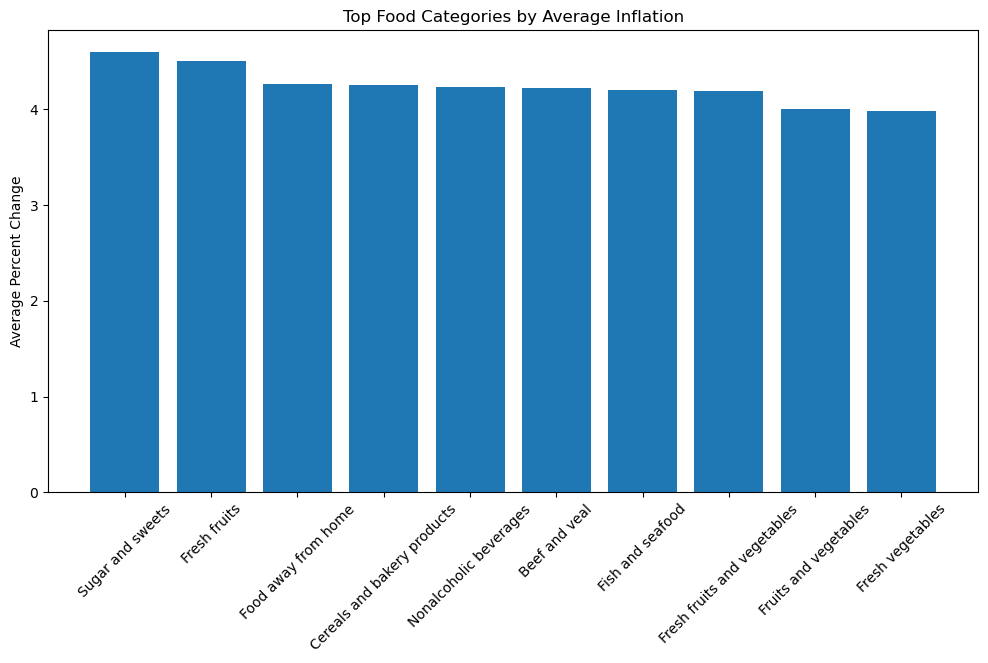

In [28]:
top10 = avg_cpi.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["Consumer Price Index item"],
        top10["Percent change"])

plt.xticks(rotation=45)
plt.title("Top Food Categories by Average Inflation")
plt.ylabel("Average Percent Change")
plt.show()

In [30]:
cpi[
    cpi["Consumer Price Index item"]=="Eggs"
].tail(25)

,Consumer Price Index item,Year,Percent change
547,Eggs,2001,3.4
548,Eggs,2002,1.3
549,Eggs,2003,13.8
550,Eggs,2004,6.2
551,Eggs,2005,-13.7
552,Eggs,2006,4.9
553,Eggs,2007,29.2
554,Eggs,2008,14.0
555,Eggs,2009,-14.7
556,Eggs,2010,1.5


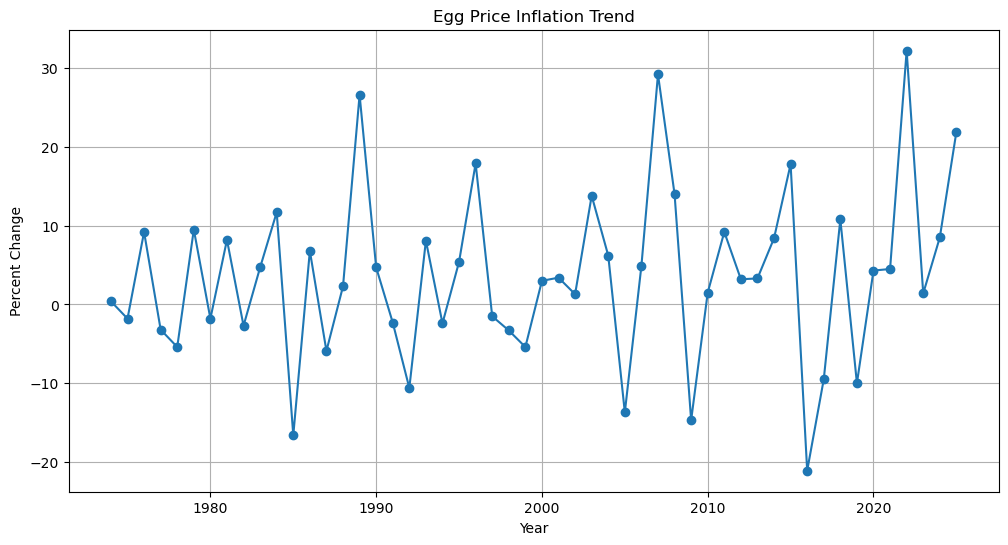

In [31]:
eggs = cpi[
    cpi["Consumer Price Index item"] == "Eggs"
]

plt.figure(figsize=(12,6))

plt.plot(
    eggs["Year"],
    eggs["Percent change"],
    marker="o"
)

plt.title("Egg Price Inflation Trend")
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.grid(True)

plt.show()

In [40]:
categories = [
    "Eggs",
    "Dairy products",
    "Fresh fruits",
    "Fresh vegetables"
]

comparison = cpi[
    cpi["Consumer Price Index item"].isin(categories)
]

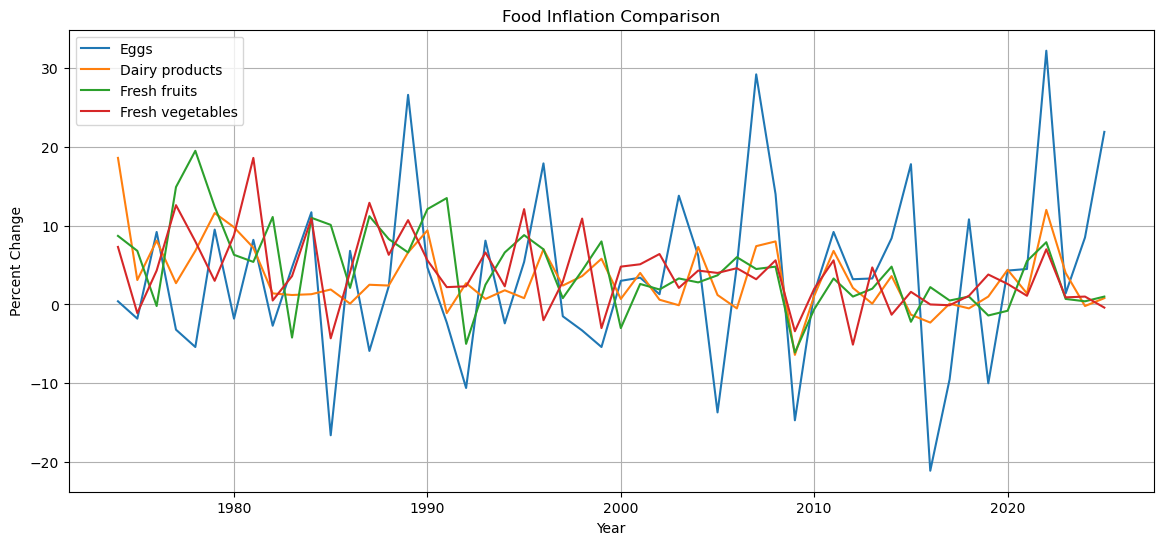

In [42]:
plt.figure(figsize=(14,6))

for cat in categories:
    temp = comparison[
        comparison["Consumer Price Index item"] == cat
    ]

    plt.plot(
        temp["Year"],
        temp["Percent change"],
        label=cat
    )

plt.legend()
plt.title("Food Inflation Comparison")
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.grid(True)

plt.show()

In [43]:
avg_cpi.head(10)

,Consumer Price Index item,Percent change
21,Sugar and sweets,4.598077
9,Fresh fruits,4.507692
8,Food away from home,4.269231
2,Cereals and bakery products,4.257692
15,Nonalcoholic beverages,4.230769
1,Beef and veal,4.223077
6,Fish and seafood,4.207692
10,Fresh fruits and vegetables,4.192308
12,Fruits and vegetables,4.003846
11,Fresh vegetables,3.986538


In [44]:
avg_cpi.tail(10)

,Consumer Price Index item,Percent change
16,Other foods,3.807692
7,Food at home,3.655769
4,Eggs,3.584615
13,Meats,3.573077
14,"Meats, poultry, and fish",3.482692
3,Dairy products,3.340385
17,Other meats,3.236538
18,Pork,2.980769
19,Poultry,2.828846
20,Processed fruits and vegetables,2.666667


In [45]:
print("Total Categories:", cpi["Consumer Price Index item"].nunique())

print("Average Inflation:",
      round(cpi["Percent change"].mean(),2))

print("Highest Inflation Year:",
      cpi.loc[cpi["Percent change"].idxmax()])

print("Lowest Inflation Year:",
      cpi.loc[cpi["Percent change"].idxmin()])

Total Categories: 22
Average Inflation: 3.82
Highest Inflation Year: Consumer Price Index item    Sugar and sweets
Year                                     1974
Percent change                           52.4
Name: 936, dtype: object
Lowest Inflation Year: Consumer Price Index item    Eggs
Year                         2016
Percent change              -21.1
Name: 562, dtype: object
